# **Análise de Riscos usando Inteligência Artificial - Boosted Trees**
# PARTE 2: Treinamento, tuning e avaliação do modelo


## **Setup Inicial do ambiente**


Este notebook é a segunda parte do exercício em sala sobre análise de riscos, focado na implementação e otimização de modelos de Machine Learning utilizando árvores impulsionadas (Boosted Trees). Aqui, exploraremos o treinamento, o ajuste fino de hiperparâmetros (tuning) e a avaliação detalhada do modelo, utilizando o dataset `df_final.pkl` que foi preparado na primeira parte. O objetivo é construir um modelo robusto para identificar riscos de processos irregulares.

### Montando o Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')
DATA_PATH = '/content/drive/My Drive/ColabData'

ModuleNotFoundError: No module named 'google.colab'

Neste passo, montamos o Google Drive para que o notebook possa acessar arquivos armazenados na sua conta do Google Drive. Isso é essencial para carregar o dataset `df_final.pkl` que foi salvo anteriormente.

- `drive.mount('/content/drive')`: Monta o Google Drive no caminho especificado dentro do ambiente Colab.
- `DATA_PATH`: Define a variável `DATA_PATH` com o caminho para a pasta onde o dataset está armazenado no seu Google Drive, facilitando a organização e o acesso aos arquivos.

### Imports Iniciais

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
%matplotlib inline

Aqui, importamos as bibliotecas Python essenciais que serão utilizadas ao longo deste notebook para manipulação de dados, visualização e construção do modelo:

- `matplotlib.pyplot as plt`: Para criar gráficos e visualizações.
- `pandas as pd`: Para manipulação e análise de dados tabulares (DataFrames).
- `numpy as np`: Para operações numéricas e matemáticas, especialmente com arrays.
- `os`: Para interagir com o sistema operacional, como manipulação de caminhos de arquivos.
- `%matplotlib inline`: Um comando mágico do IPython/Colab que garante que os gráficos do matplotlib sejam exibidos diretamente no notebook.

### Lendo o dataset

In [3]:
df = pd.read_pickle(os.path.join(DATA_PATH,'df_final.pkl'))

Nesta célula, carregamos o dataset que será utilizado para o treinamento e avaliação do modelo. O arquivo `df_final.pkl` é um DataFrame do pandas serializado, que contém os dados pré-processados da primeira parte do exercício.

- `os.path.join(DATA_PATH,'df_final.pkl')`: Constrói o caminho completo para o arquivo `df_final.pkl` usando a variável `DATA_PATH` definida anteriormente.
- `pd.read_pickle()`: Carrega o DataFrame a partir do arquivo `.pkl`.
- O DataFrame carregado (`df`) agora contém todas as características e a variável `target` que serão usadas para construir nosso modelo de classificação de risco.

## **Train/Test Split**
Vamos separar uma parte dos dados para avaliarmos a performance final do modelo.

In [4]:
from sklearn.model_selection import train_test_split
train_test_ratio = 0.8
df_train, df_test = train_test_split(df, test_size=1-train_test_ratio, random_state=0,
                               stratify=df.target)
len(df_train), len(df_test)

(19428, 4857)

Antes de treinar qualquer modelo, é crucial dividir o dataset em conjuntos de treinamento e teste. Isso nos permite treinar o modelo em uma parte dos dados e avaliar seu desempenho em dados 'novos' e não vistos, o que fornece uma estimativa mais realista de como o modelo se comportará em cenários reais.

- `train_test_split`: Função do `sklearn.model_selection` que realiza a divisão do dataset.
- `train_test_ratio = 0.8`: Define que 80% dos dados serão usados para treinamento e 20% para teste.
- `test_size=1-train_test_ratio`: Calcula o tamanho do conjunto de teste.
- `random_state=0`: Garante que a divisão dos dados seja a mesma toda vez que o código for executado, tornando os resultados reproduzíveis.
- `stratify=df.target`: Essencial para problemas de classificação, **especialmente com classes desbalanceadas**. Garante que a proporção das classes (neste caso, `target`) seja a mesma nos conjuntos de treinamento e teste. Isso evita que um conjunto tenha muito mais exemplos de uma classe do que outro.
- `len(df_train), len(df_test)`: Exibe o número de amostras em cada conjunto.

In [5]:
features = [ x for x in df.columns if x != 'target']
features

['v1',
 'v2',
 'bin1',
 'bin2',
 'bin3',
 'bin4',
 'bin5',
 'bin6',
 'bin7',
 'bin8',
 'bin9',
 'bin10',
 'bin11',
 'bin12',
 'bin13',
 'bin14',
 'bin15',
 'bin16',
 'bin17',
 'bin18',
 'bin19',
 'bin20',
 'bin21',
 'bin22',
 'bin23',
 'bin24',
 'bin25',
 'bin26',
 'bin27',
 'bin28',
 'bin29',
 'bin30',
 'bin31',
 'qtd1',
 'qtd2',
 'qtd3',
 'qtd4',
 'qtd5',
 'qtd6',
 'qtd7',
 'qtd8',
 'qtd9',
 'qtd10',
 'qtd11',
 'qtd12',
 'qtd13',
 'qtd14',
 't1',
 't2',
 'qtd18',
 'qtd15',
 'qtd16',
 'qtd17',
 'cat1_1',
 'cat1_2',
 'cat2_1',
 'cat2_2',
 'cat2_3',
 'cat2_4',
 'cat3_1',
 'cat3_2',
 'cat3_3',
 'cat3_4',
 'cat3_5',
 'cat3_7']

Aqui, definimos quais colunas do nosso DataFrame serão usadas como *features* (variáveis preditoras) para o modelo. A coluna 'target' é excluída, pois ela é a variável que queremos prever.

- `features = [x for x in df.columns if x != 'target']`: Cria uma lista contendo todos os nomes das colunas do DataFrame `df`, exceto a coluna 'target'. Essa lista será usada para selecionar as colunas de entrada para o modelo XGBoost.

## **Treinamento Inicial**

### Parâmetros Iniciais

Nos passos iniciais usaremos a inteface do XGBoost compatível com o scikit-learn

Nesta seção, realizaremos o treinamento inicial do modelo XGBoost. O XGBoost é uma implementação otimizada de gradient boosting, uma técnica poderosa para construção de modelos preditivos. Começaremos com um conjunto de parâmetros base para estabelecer uma performance inicial.

In [30]:
from xgboost.sklearn import XGBClassifier

xgb1 = XGBClassifier(
 learning_rate =0.1,   # tune
 n_estimators=10,      # tune
 max_depth=11,         # tune
 min_child_weight=2,   # tune
 subsample=0.8,        # tune
 colsample_bytree=0.5, # tune
 objective= 'binary:logistic',
 n_jobs=4,
 scale_pos_weight=df_train.target.value_counts()[0]/df_train.target.value_counts()[1],
 random_state=27,
 eval_metric="auc")

Instanciamos o modelo `XGBClassifier` com alguns parâmetros iniciais. Estes parâmetros controlam o comportamento do algoritmo e serão ajustados posteriormente no processo de *tuning*:

- `learning_rate`: Taxa de aprendizado, que reduz o peso das etapas de Boosting. Um valor menor exige mais estimadores.
- `n_estimators`: Número de árvores de decisão que serão construídas (ou estágios de Boosting).
- `max_depth`: Profundidade máxima de cada árvore. Controla a complexidade do modelo.
- `min_child_weight`: Peso mínimo da instância (soma de hessianas) em um nó filho. Usado para controlar overfitting. Um valor maior evita que o modelo aprenda relações muito específicas dos dados de treinamento.
- `subsample`: Fração de amostras que serão usadas para treinar cada árvore. Ajuda a reduzir o overfitting.
- `colsample_bytree`: Fração de características (colunas) que serão aleatoriamente amostradas para construir cada árvore. Também ajuda a controlar o overfitting.
- `objective`: Função objetivo a ser minimizada. 'binary:logistic' é usado para classificação binária (saída de probabilidade).
- `n_jobs`: Número de threads a serem usadas para processamento paralelo.
- `scale_pos_weight`: Parâmetro crucial para lidar com datasets desbalanceados. Ele pondera as amostras da classe positiva para equilibrar as classes, sendo calculado como `(número de amostras negativas) / (número de amostras positivas)`.
- `eval_metric`: Métrica usada para avaliação durante o treinamento do modelo. Aqui, 'auc' (Area Under the Receiver Operating Characteristic Curve) é utilizada, que é uma métrica comum para problemas de classificação binária, especialmente em bases de dados desbalanceadas. Um valor de AUC próximo de 1 indica um modelo com excelente capacidade de discriminar entre as classes.

### Treinamento Básico

In [31]:
xgb1.fit(df_train[features], df_train['target'])

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.5, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=11,
              max_leaves=None, min_child_weight=2, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=10,
              n_jobs=4, num_parallel_tree=None, ...)

Nesta etapa, treinamos o modelo XGBoost com os dados de treinamento (`df_train[features]`) e a variável `target`.

### Importância das Variáveis

A importância das variáveis (Feature Importance) é uma métrica que indica a relevância de cada *feature* para o modelo. Ela nos ajuda a entender quais características são mais decisivas na tomada de decisão do classificador.

- `xgb1.feature_importances_`: Atributo do modelo treinado que contém as importâncias das features.
- `pd.Series(...)`: Converte as importâncias em uma série pandas com os nomes das features como índice.
- `.sort_values(ascending=False)`: Ordena as features da mais importante para a menos importante.
- `feat_imp.plot(kind='bar', ...)`: Gera um gráfico de barras visualizando a importância de cada feature, facilitando a identificação das variáveis mais influentes.

Text(0, 0.5, 'Feature Importance Score')

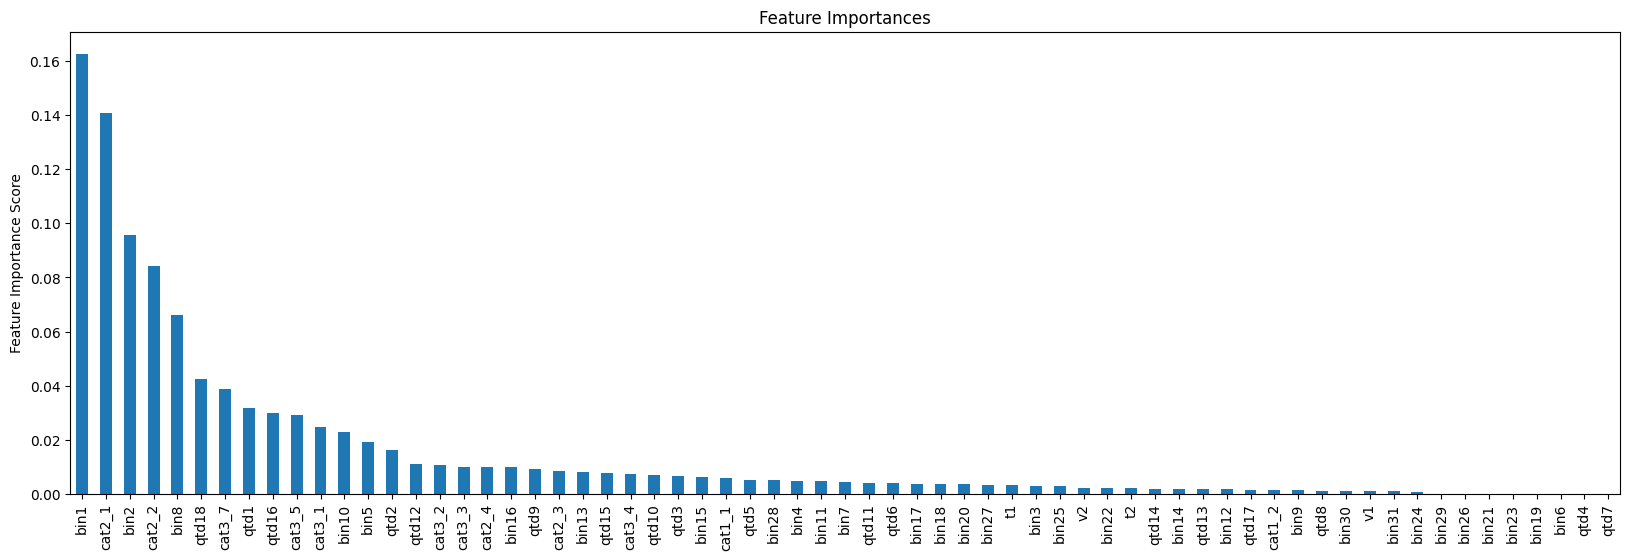

In [32]:
plt.figure(figsize=(20, 6))
feat_imp = pd.Series(xgb1.feature_importances_, index=features).sort_values(ascending=False)
feat_imp.plot(kind='bar', title='Feature Importances')

plt.ylabel('Feature Importance Score')

### Avaliação

Após o treinamento, é fundamental avaliar o desempenho do modelo nos dados de teste, que o modelo não 'viu' durante o treinamento. Isso nos dá uma estimativa mais realista de sua capacidade de generalização.

In [33]:
from sklearn import metrics

probs = xgb1.predict_proba(df_test[features])[:,1]

auc_score = metrics.roc_auc_score(df_test.target, probs)

auc_score

np.float64(0.968315505449789)

A Área Sob a Curva ROC (AUC - Area Under the Receiver Operating Characteristic Curve) é uma métrica de avaliação comum para problemas de classificação binária, especialmente quando as classes estão desbalanceadas. Um valor de AUC próximo de 1.0 indica um modelo com excelente poder discriminatório, enquanto um valor próximo de 0.5 sugere um desempenho aleatório.

- `probs = xgb1.predict_proba(df_test[features])[:,1]`: Obtém as probabilidades de previsão para a classe positiva (`target = 1`) no conjunto de teste.
- `metrics.roc_auc_score(df_test.target, probs)`: Calcula o valor da AUC comparando as classes reais (`df_test.target`) com as probabilidades previstas.

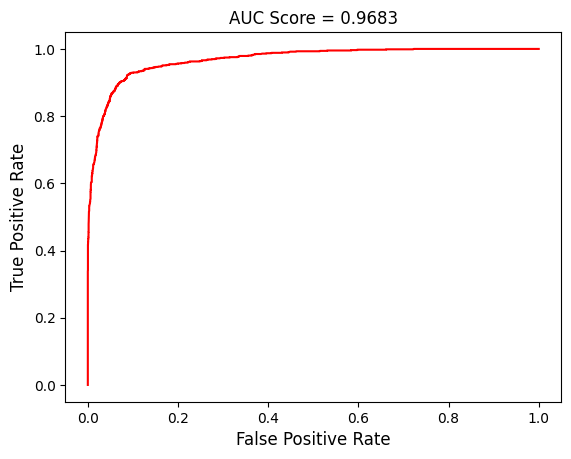

In [34]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(df_test['target'], probs)
thresholds = np.append(thresholds,[1])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title("AUC Score = {:.4f}".format(auc_score))
p=plt.plot(fpr, tpr, 'r', label='Precision')

A Curva ROC (Receiver Operating Characteristic) é um gráfico que ilustra o desempenho de um modelo de classificação em todos os limiares de classificação. Ela plota a Taxa de Verdadeiros Positivos (TPR - True Positive Rate) contra a Taxa de Falsos Positivos (FPR - False Positive Rate) em diferentes pontos de corte.

- `roc_curve(df_test['target'], probs)`: Calcula as taxas de FPR e TPR para vários limiares de probabilidade.
- O gráfico resultante mostra a capacidade do modelo de distinguir entre as classes. Um modelo ideal teria uma curva que passa pelo canto superior esquerdo (TPR alta, FPR baixa).

Vamos avaliar a matriz de confusão para alguns thresholds:

A Matriz de Confusão é uma ferramenta essencial para entender o desempenho de um modelo de classificação. Ela nos mostra o número de verdadeiros positivos (TP), verdadeiros negativos (TN), falsos positivos (FP) e falsos negativos (FN).

Em um cenário de auditoria baseado em risco, onde a equipe precisa concentrar seus esforços naqueles processos com maior chance de possuírem alguma ilegalidade, a Matriz de Confusão nos permite realizar uma **análise de custo e benefício**:

- **Verdadeiros Positivos (TP)**: Casos de processos irregulares que o modelo previu corretamente como irregulares. Estes são os `Ilegais encontrados`, o **benefício** da auditoria.
- **Falsos Positivos (FP)**: Casos de processos regulares que o modelo previu incorretamente como irregulares. Estes representam `esforço de análise despendido` em processos que não apresentaram ilegalidade, um `custo` sem benefício direto.
- **Falsos Negativos (FN)**: Casos de processos irregulares que o modelo previu incorretamente como regulares. Estes são os `Ilegais que passaram`, ou seja, oportunidades perdidas de identificar fraudes.
- **Verdadeiros Negativos (TN)**: Casos de processos regulares que o modelo previu corretamente como regulares. Estes não são auditados, poupando recursos.

- `pred_threshold(x, cutoff)`: Uma função auxiliar para classificar as probabilidades em 0 ou 1 com base em um `cutoff` (limiar).
- O loop itera por diferentes `thresholds` (limiares de corte), aplicando a função `pred_threshold` para converter as probabilidades em previsões de classes.
- `confusion_matrix(df_test['target'], preds)`: Calcula a matriz de confusão para cada limiar.
- São calculadas e impressas as métricas:
    - **Precisão (Precision)**: `TP / (TP + FP)` - A proporção de previsões positivas corretas entre todas as previsões positivas. **Neste contexto de auditoria, a `Precision` é a métrica mais crucial de sucesso, pois mede a eficiência do esforço de análise: quantos dos processos que foram sugeridos para análise ('Sugestão de análise') realmente eram ilegais ('Ilegais encontrados').**
    - **Recall/Sensibilidade (Recall/Sensitivity)**: `TP / (TP + FN)` - A proporção de verdadeiros positivos que foram corretamente identificados. Representa a capacidade do modelo de encontrar todos os processos irregulares existentes.
    - **Especificidade (Especificity)**: `TN / (TN + FP)` - A proporção de verdadeiros negativos que foram corretamente identificados. Representa a capacidade do modelo de identificar processos regulares.
- Estas métricas nos ajudam a avaliar o balanço entre identificar corretamente os casos positivos (benefício) e evitar alarmes falsos (custo), dependendo do limiar escolhido, e a otimizar a alocação de recursos de auditoria.

Em um cenário de auditoria real, o `threshold` (limiar de corte) seria definido de forma a otimizar a ocupação da capacidade de análise da equipe. Por exemplo, se uma equipe de auditoria consegue analisar 700 processos por mês, o `threshold` deveria ser escolhido de forma a gerar uma 'Sugestão de análise' (`TP + FP`) próxima a 700, garantindo que o recurso humano seja utilizado de forma eficiente e focada nos casos mais prováveis de irregularidade.

In [35]:
from sklearn.metrics import confusion_matrix
def pred_threshold (x,cutoff):
    if x > cutoff:
        return 1
    else:
        return 0


for threshold in [0.50, 0.6, 0.7, 0.8]:
  preds = [pred_threshold(x, threshold) for x in probs]
  cm = confusion_matrix(df_test['target'], preds)
  np.set_printoptions(precision=2)
  print('\n**TEST** Confusion matrix, threshold =', threshold)
  print(cm)
  tp = cm[1,1]
  tn = cm[0,0]
  fp = cm[0,1]
  fn = cm[1,0]
  print('tp= %d tn= %d fp= %d fn= %d' % (tp, tn, fp, fn))
  print("precision:", tp/(tp+fp))
  print("recall/sensitivity:", tp/(tp+fn))
  print("especificity:", tn/(tn+fp))
  print("Total de Atos a analisar:",len(df_test))
  print("Sugestão de análise:",tp+fp)
  print("Ilegais encontrados:",tp)
  print("Ilegais que passaram:",fn)



**TEST** Confusion matrix, threshold = 0.5
[[3689  310]
 [  82  776]]
tp= 776 tn= 3689 fp= 310 fn= 82
precision: 0.714548802946593
recall/sensitivity: 0.9044289044289044
especificity: 0.9224806201550387
Total de Atos a analisar: 4857
Sugestão de análise: 1086
Ilegais encontrados: 776
Ilegais que passaram: 82

**TEST** Confusion matrix, threshold = 0.6
[[3804  195]
 [ 129  729]]
tp= 729 tn= 3804 fp= 195 fn= 129
precision: 0.788961038961039
recall/sensitivity: 0.8496503496503497
especificity: 0.9512378094523631
Total de Atos a analisar: 4857
Sugestão de análise: 924
Ilegais encontrados: 729
Ilegais que passaram: 129

**TEST** Confusion matrix, threshold = 0.7
[[3922   77]
 [ 253  605]]
tp= 605 tn= 3922 fp= 77 fn= 253
precision: 0.8870967741935484
recall/sensitivity: 0.7051282051282052
especificity: 0.9807451862965741
Total de Atos a analisar: 4857
Sugestão de análise: 682
Ilegais encontrados: 605
Ilegais que passaram: 253

**TEST** Confusion matrix, threshold = 0.8
[[3998    1]
 [ 512  

O resultado parece bom, mas será que dá para melhorar?

## ***Hyperparameter Tuning***

Vamos implementar o refinamento dos parâmetros usando ***grid search*** e ***cross validation***.

O resultado do modelo inicial é promissor, com um bom AUC e métricas da matriz de confusão. No entanto, em Machine Learning, é quase sempre possível otimizar o desempenho do modelo ajustando seus *hiperparâmetros*. Esta seção se dedicará a refinar os parâmetros do XGBoost para buscar um desempenho ainda melhor.

### ***Grid search***

O ***Grid Search*** é uma técnica de otimização de hiperparâmetros que funciona explorando sistematicamente todas as combinações possíveis de um conjunto de valores pré-definidos para cada hiperparâmetro. Ele cria uma "grade" (grid) de todos os valores de hiperparâmetros que você deseja testar, e então treina e avalia o modelo para cada combinação. A combinação que resulta no melhor desempenho (geralmente medida por uma métrica de validação cruzada) é selecionada como a ideal.

Embora o Grid Search seja exaustivo e garanta que você encontre a melhor combinação dentro do espaço de busca definido, ele pode ser computacionalmente caro, especialmente quando há muitos hiperparâmetros ou muitos valores para cada um.

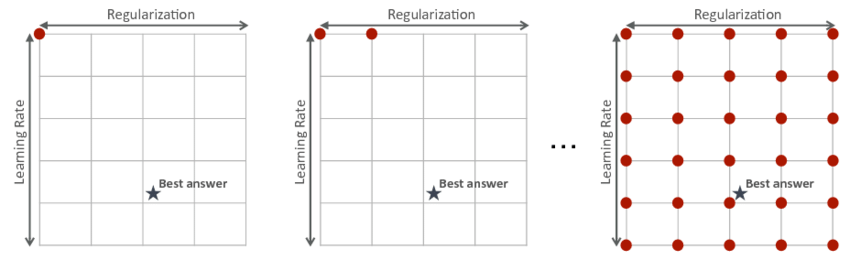

### ***Cross validation***

**Validação Cruzada (Cross-validation)** é uma técnica estatística utilizada para estimar a performance generalizada de um modelo preditivo. Ao invés de dividir o dataset uma única vez em treino e teste (como no `train_test_split`), a validação cruzada divide o dataset em múltiplos subconjuntos. O processo mais comum é o `k-fold Cross-validation`:

1. O dataset é dividido em `k` 'folds' (dobras) de tamanhos aproximadamente iguais.
2. Para cada um dos `k` folds:
    - Um fold é usado como conjunto de validação (teste).
    - Os `k-1` folds restantes são combinados para formar o conjunto de treinamento.
    - O modelo é treinado no conjunto de treinamento e avaliado no conjunto de validação.
3. O processo é repetido `k` vezes, garantindo que cada fold seja usado exatamente uma vez como conjunto de validação.

Os resultados de cada iteração são então combinados (por exemplo, tirando a média) para produzir uma estimativa mais robusta e menos enviesada do desempenho do modelo em dados não vistos. A validação cruzada é essencial para evitar o overfitting e para garantir que a avaliação do modelo seja confiável, especialmente quando o tamanho do dataset é limitado.

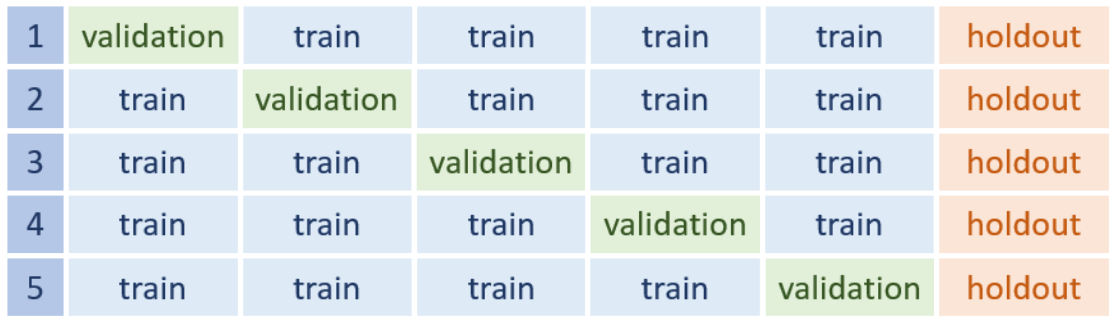

### Holdout

O método **Holdout** é uma técnica mais simples de validação de modelos, onde o dataset é dividido em dois conjuntos distintos: um para treinamento (maior parte dos dados) e outro para teste (menor parte dos dados). Ao contrário da Validação Cruzada, a divisão é feita apenas uma vez. O modelo é treinado exclusivamente no conjunto de treinamento e avaliado no conjunto de teste. O desempenho reportado é o resultado dessa única avaliação.

É importante notar que, em algumas abordagens, especialmente após a fase de otimização de hiperparâmetros com validação cruzada, uma porção do dataset (o "holdout") pode ser reservada desde o início para uma **avaliação final, totalmente isolada** dos dados utilizados no treinamento e em todas as etapas de validação cruzada. Este conjunto de holdout garante uma estimativa imparcial do desempenho do modelo em dados verdadeiramente não vistos.

### Implementando o ***grid search*** com ***CV***

In [36]:
from sklearn.model_selection import GridSearchCV

xgb1.get_params()

{'objective': 'binary:logistic',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': 0.5,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': True,
 'eval_metric': 'auc',
 'feature_types': None,
 'feature_weights': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': 0.1,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': 11,
 'max_leaves': None,
 'min_child_weight': 2,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': 10,
 'n_jobs': 4,
 'num_parallel_tree': None,
 'random_state': 27,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': np.float64(4.664139941690962),
 'subsample': 0.8,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}

Para realizar o ajuste fino dos hiperparâmetros, utilizaremos o `GridSearchCV` do `scikit-learn`. Esta técnica permite testar sistematicamente diferentes combinações de hiperparâmetros e encontrar aquela que resulta no melhor desempenho do modelo, utilizando validação cruzada (CV).

Para evitar que o processo de refino se torne excessivamente lento, faremos o `GridSearchCV` por partes. Otimizaremos um subconjunto relacionado de hiperparâmetros por vez, baseando as rodadas subsequentes nos melhores resultados das anteriores. Você pode observar o restante do notebook para ver como essa estratégia é implementada em etapas.

- `xgb1.get_params()`: Exibe os parâmetros atuais do modelo `xgb1` que foi instanciado e treinado inicialmente. Isso nos ajuda a saber quais parâmetros podemos otimizar.

### 1a. Rodada ***max_depth*** e ***min_child_weight***

In [38]:
param_grid = {
     'max_depth': [6, 7, 8, 9, 10, 11, 12, 13],
     'min_child_weight': [1, 2, 3],
}
gs = GridSearchCV(
        estimator=xgb1,
        param_grid=param_grid,
        cv=5,
        n_jobs=8,
        scoring='roc_auc',
        verbose=1
)
gs_result = gs.fit(df_train[features], df_train['target'])

print("\nMelhores parâmetros encontrados:", gs_result.best_params_, "AUC:", gs_result.best_score_)

print("\nDetalhes dos resultados de cada fold para cada combinação:")
for i, params in enumerate(gs_result.cv_results_['params']):
    print(f"\nCandidato {i+1} com parâmetros: {params}")
    for j in range(gs.n_splits_):
        score = gs_result.cv_results_[f'split{j}_test_score'][i]
        print(f"  Fold {j+1} - AUC: {score:.4f}")
    print(f"  Média de AUC: {gs_result.cv_results_['mean_test_score'][i]:.4f}")
    print(f"  Desvio padrão da AUC: {gs_result.cv_results_['std_test_score'][i]:.4f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Melhores parâmetros encontrados: {'max_depth': 13, 'min_child_weight': 1} AUC: 0.9673579763418004

Detalhes dos resultados de cada fold para cada combinação:

Candidato 1 com parâmetros: {'max_depth': 6, 'min_child_weight': 1}
  Fold 1 - AUC: 0.9591
  Fold 2 - AUC: 0.9574
  Fold 3 - AUC: 0.9565
  Fold 4 - AUC: 0.9579
  Fold 5 - AUC: 0.9610
  Média de AUC: 0.9584
  Desvio padrão da AUC: 0.0016

Candidato 2 com parâmetros: {'max_depth': 6, 'min_child_weight': 2}
  Fold 1 - AUC: 0.9588
  Fold 2 - AUC: 0.9574
  Fold 3 - AUC: 0.9561
  Fold 4 - AUC: 0.9587
  Fold 5 - AUC: 0.9613
  Média de AUC: 0.9585
  Desvio padrão da AUC: 0.0017

Candidato 3 com parâmetros: {'max_depth': 6, 'min_child_weight': 3}
  Fold 1 - AUC: 0.9589
  Fold 2 - AUC: 0.9574
  Fold 3 - AUC: 0.9560
  Fold 4 - AUC: 0.9588
  Fold 5 - AUC: 0.9613
  Média de AUC: 0.9585
  Desvio padrão da AUC: 0.0018

Candidato 4 com parâmetros: {'max_depth': 7, 'min_child_weight':

Nesta primeira rodada de *grid search*, vamos focar no ajuste dos hiperparâmetros `max_depth` (profundidade máxima da árvore) e `min_child_weight` (peso mínimo de instâncias em um nó filho). Estes parâmetros são cruciais para controlar a complexidade do modelo e evitar overfitting.

- `param_grid`: Um dicionário que define as combinações de parâmetros que serão testadas.
- `GridSearchCV`: É instanciado com o estimador (`xgb1`), o dicionário de parâmetros (`param_grid`), `cv=5` (validação cruzada com 5 folds), `n_jobs=8` (para usar múltiplos núcleos de CPU para paralelizar o processo) e `scoring='roc_auc'` (usando AUC como métrica para selecionar o melhor modelo).
- `gs.fit(...)`: Treina o modelo para cada combinação de parâmetros no `param_grid`.
- `gs_result.best_params_`: Exibe a melhor combinação de parâmetros encontrada.
- `gs_result.best_score_`: Exibe o valor da AUC obtido com a melhor combinação de parâmetros.

In [39]:
param_grid = {
     'max_depth': [13, 15, 17],
     'min_child_weight': [0.5, 1],
}
gs = GridSearchCV(
        estimator=xgb1,
        param_grid=param_grid,
        cv=5,
        n_jobs=8,
        scoring='roc_auc',
        verbose=1
)
gs_result = gs.fit(df_train[features], df_train['target'])

print("\nMelhores parâmetros encontrados:", gs_result.best_params_, "AUC:", gs_result.best_score_)


Fitting 5 folds for each of 6 candidates, totalling 30 fits

Melhores parâmetros encontrados: {'max_depth': 15, 'min_child_weight': 1} AUC: 0.9676775707799086


### 2a. Rodada ***subsample*** e ***colsample_bytree***



Nesta segunda rodada de *grid search*, mantemos os melhores valores encontrados para `max_depth` e `min_child_weight` e agora focamos no ajuste de `subsample` (fração de amostras para cada árvore) e `colsample_bytree` (fração de colunas para cada árvore).

- O `param_grid` agora inclui os valores ótimos de `max_depth` e `min_child_weight` e explora diferentes combinações para `subsample` e `colsample_bytree`.
- O processo de `GridSearchCV` é repetido para encontrar a melhor combinação desses novos parâmetros, visando um equilíbrio entre variância e viés.

In [41]:
param_grid = {
     'max_depth': [15],
     'min_child_weight': [1],
     'subsample': [0.6, 0.7, 0.8, 0.9, 1],
     'colsample_bytree': [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1],

}
gs = GridSearchCV(
        estimator=xgb1,
        param_grid=param_grid,
        cv=5,
        n_jobs=8,
        scoring='roc_auc',
        verbose=5
)
gs_result = gs.fit(df_train[features], df_train['target'], verbose = 5)

print(gs_result.best_params_, "AUC:", gs_result.best_score_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
{'colsample_bytree': 0.6, 'max_depth': 15, 'min_child_weight': 1, 'subsample': 1} AUC: 0.9704816663991436


### 3a. Rodada: ***n_estimators*** e ***learning_rate***
Esta rodada vamos fazer usando a interface padrão do XGBoost, com o recurso ***early_stopping***. Não usaremos ***grid search***.

Vamos reduzir o Learning Rate e achar a melhor quantidade de árvores com CV.

Esta rodada final de ajuste de hiperparâmetros é um pouco diferente, pois focaremos em `n_estimators` (número de árvores) e `learning_rate` (taxa de aprendizado) usando a interface nativa do XGBoost (`xgboost as xgb`) com um recurso muito útil: ***early_stopping***.

- Primeiramente, atualizamos o modelo `xgb1` com os melhores parâmetros `max_depth`, `min_child_weight`, `subsample` e `colsample_bytree` encontrados nas rodadas anteriores do *grid search*.
- Reduzimos o `learning_rate` (para 0.01) para permitir que o modelo aprenda de forma mais gradual e precise. Ao fazer isso, geralmente precisamos de um maior `n_estimators` (número de árvores). Definimos um valor alto inicial (1000) que será ajustado pelo *early stopping*.
- `xgb.DMatrix`: Prepara os dados no formato otimizado exigido pela API nativa do XGBoost.
- `xgb.cv()`: Realiza a validação cruzada. `early_stopping_rounds=10` significa que o treinamento será parado se a métrica de avaliação (`auc`) no conjunto de validação não melhorar por 10 rodadas consecutivas. Isso evita o overfitting e encontra o `n_estimators` ideal.
- O `n_estimators` do modelo `xgb1` é atualizado com o número ótimo de árvores determinado pelo *early stopping*.

In [43]:
import xgboost as xgb

# Armazenando os parametros encontrados até o momento
xgb1.set_params(max_depth=15)
xgb1.set_params(min_child_weight=1)
xgb1.set_params(subsample=1)
xgb1.set_params(colsample_bytree=1)

# Setando a nova LR e definindo uma quantidade máxima de árvores
xgb1.set_params(learning_rate=0.01)
xgb1.set_params(n_estimators=1000)

xgb_param = xgb1.get_xgb_params()

# Preparando os dados no padrão do XGB
xgtrain = xgb.DMatrix(df_train[features].values, label=df_train['target'].values)

cvresult = xgb.cv(xgb_param, xgtrain, num_boost_round=xgb1.get_params()['n_estimators'], nfold=5,
                  metrics='auc', early_stopping_rounds=10, verbose_eval=10)

print("Optimal num boost rounds=", cvresult.shape[0])

# Armazenando numero de árvores encontrado
xgb1.set_params(n_estimators=cvresult.shape[0])

[0]	train-auc:0.98425+0.00114	test-auc:0.96004+0.00522
[10]	train-auc:0.98578+0.00150	test-auc:0.96041+0.00468
[20]	train-auc:0.98777+0.00147	test-auc:0.96121+0.00413
[30]	train-auc:0.98930+0.00147	test-auc:0.96200+0.00453
[40]	train-auc:0.99050+0.00149	test-auc:0.96259+0.00433
[50]	train-auc:0.99134+0.00129	test-auc:0.96333+0.00429
[60]	train-auc:0.99199+0.00129	test-auc:0.96359+0.00442
[70]	train-auc:0.99307+0.00058	test-auc:0.96460+0.00379
[80]	train-auc:0.99365+0.00046	test-auc:0.96498+0.00392
[90]	train-auc:0.99405+0.00044	test-auc:0.96542+0.00377
[100]	train-auc:0.99443+0.00046	test-auc:0.96591+0.00365
[110]	train-auc:0.99478+0.00045	test-auc:0.96609+0.00369
[120]	train-auc:0.99506+0.00046	test-auc:0.96612+0.00371
[130]	train-auc:0.99532+0.00043	test-auc:0.96633+0.00357
[140]	train-auc:0.99559+0.00038	test-auc:0.96640+0.00350
[150]	train-auc:0.99590+0.00039	test-auc:0.96653+0.00347
[160]	train-auc:0.99614+0.00039	test-auc:0.96676+0.00339
[170]	train-auc:0.99636+0.00035	test-auc:0

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None, colsample_bytree=1,
              device=None, early_stopping_rounds=None, enable_categorical=True,
              eval_metric='auc', feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=15, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=227, n_jobs=4,
              num_parallel_tree=None, ...)

Com os hiperparâmetros otimizados através do *grid search* e da validação cruzada, agora treinaremos o modelo XGBoost final utilizando todos os dados de treinamento (`df_train`) e os melhores parâmetros encontrados. Em seguida, avaliaremos seu desempenho final no conjunto de teste (`df_test`).

- `xgb1.fit(...)`: Treina o modelo com os parâmetros ajustados.
- `xgb1.predict_proba(...)`: Gera as probabilidades para a classe positiva no conjunto de teste.
- `metrics.roc_auc_score(...)`: Calcula a AUC final no conjunto de teste para verificar a performance do modelo otimizado. Espera-se que este valor seja ligeiramente melhor ou mais robusto que o modelo inicial.

### Treinamento Final: Treinando com todos os dados, com os melhores parâmetros
Volteremos para a interface scikit-learn

In [44]:
#Fit the algorithm on the data
xgb1.fit(df_train[features], df_train['target'])

#Predict training set:
probs = xgb1.predict_proba(df_test[features])[:,1]

#Print model report:
print ("\nModel Report")
print ("AUC Score (Test) : %f" % metrics.roc_auc_score(df_test['target'], probs))


Model Report
AUC Score (Test) : 0.970063


Assim como na avaliação inicial, exibimos novamente a importância das variáveis após o treinamento final com os hiperparâmetros otimizados. Isso pode nos dar uma visão ligeiramente diferente sobre a relevância das *features* no modelo mais robusto.

- `feat_imp.plot(kind='bar', ...)`: Gera o gráfico de barras das importâncias, permitindo comparar com a visualização anterior e identificar se a otimização dos parâmetros alterou a percepção sobre a relevância das features.

Text(0, 0.5, 'Feature Importance Score')

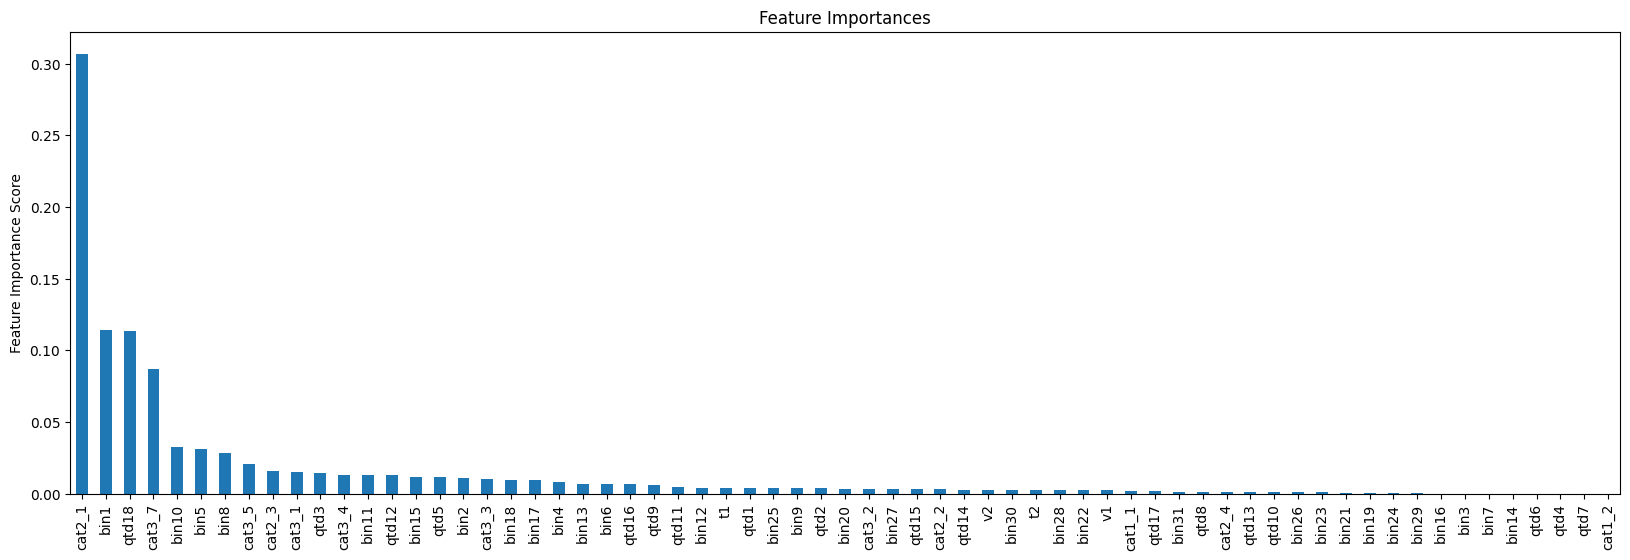

In [45]:
plt.figure(figsize=(20, 6))
feat_imp = pd.Series(xgb1.feature_importances_, index=features).sort_values(ascending=False)
feat_imp.plot(kind='bar', title='Feature Importances')
plt.ylabel('Feature Importance Score')

Repetimos a análise da matriz de confusão com o modelo final e otimizado, explorando diferentes limiares (`thresholds`). O objetivo é encontrar o ponto de corte que melhor se alinha com os objetivos de negócio, balanceando a precisão e o recall, e avaliando a quantidade de casos que seriam analisados versus os casos ilegais encontrados e os que passariam despercebidos.

- O loop e os cálculos são os mesmos da avaliação inicial, mas agora utilizando as previsões do modelo com os hiperparâmetros ajustados. Isso nos permite ver o impacto da otimização na detecção de casos positivos e negativos.

In [47]:
for threshold in [0.50, 0.6, 0.7, 0.8]:
  preds = [pred_threshold(x, threshold) for x in probs]
  cm = confusion_matrix(df_test['target'], preds)
  np.set_printoptions(precision=2)
  print('\n**TEST** Confusion matrix, threshold =', threshold)
  print(cm)
  tp = cm[1,1]
  tn = cm[0,0]
  fp = cm[0,1]
  fn = cm[1,0]
  print('tp= %d tn= %d fp= %d fn= %d' % (tp, tn, fp, fn))
  print("precision:", tp/(tp+fp))
  print("recall/sensitivity:", tp/(tp+fn))
  print("especificity:", tn/(tn+fp))
  print("Total de Atos a analisar:",len(df_test))
  print("Sugestão de análise:",tp+fp)
  print("Ilegais encontrados:",tp)
  print("Ilegais que passaram:",fn)



**TEST** Confusion matrix, threshold = 0.5
[[3724  275]
 [  86  772]]
tp= 772 tn= 3724 fp= 275 fn= 86
precision: 0.7373447946513849
recall/sensitivity: 0.8997668997668997
especificity: 0.9312328082020506
Total de Atos a analisar: 4857
Sugestão de análise: 1047
Ilegais encontrados: 772
Ilegais que passaram: 86

**TEST** Confusion matrix, threshold = 0.6
[[3776  223]
 [ 110  748]]
tp= 748 tn= 3776 fp= 223 fn= 110
precision: 0.7703398558187435
recall/sensitivity: 0.8717948717948718
especificity: 0.9442360590147537
Total de Atos a analisar: 4857
Sugestão de análise: 971
Ilegais encontrados: 748
Ilegais que passaram: 110

**TEST** Confusion matrix, threshold = 0.7
[[3827  172]
 [ 142  716]]
tp= 716 tn= 3827 fp= 172 fn= 142
precision: 0.8063063063063063
recall/sensitivity: 0.8344988344988346
especificity: 0.956989247311828
Total de Atos a analisar: 4857
Sugestão de análise: 888
Ilegais encontrados: 716
Ilegais que passaram: 142

**TEST** Confusion matrix, threshold = 0.8
[[3905   94]
 [ 212

# Distribuição Acumulada Reversa (TP + FP) vs. Threshold

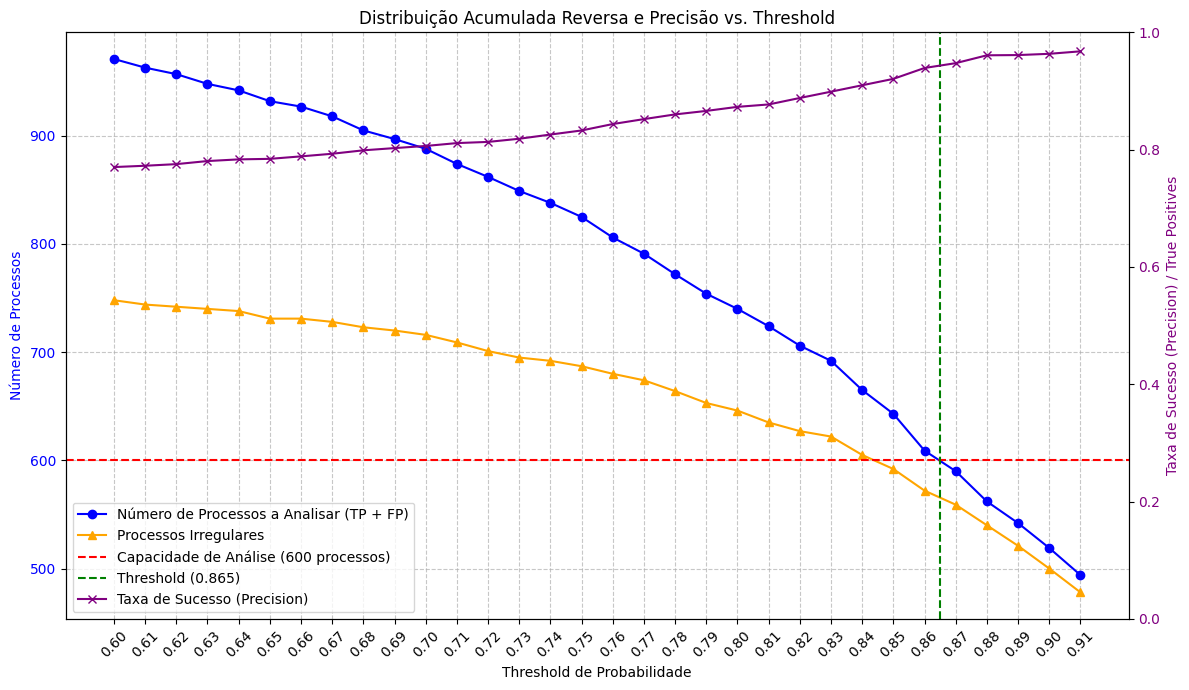

In [61]:
import matplotlib.pyplot as plt

def pred_threshold (x,cutoff):
    if x > cutoff:
        return 1
    else:
        return 0

thresholds_plot = np.arange(0.6, 0.91, 0.01) # Thresholds de 0.6 a 0.9 com passo de 0.05
processes_to_analyze = []
precision_scores = [] # New list to store precision scores
tp_scores = [] # New list to store True Positive scores

for threshold in thresholds_plot:
    preds_for_plot = [pred_threshold(x, threshold) for x in probs]
    cm_for_plot = confusion_matrix(df_test['target'], preds_for_plot)
    tp_plot = cm_for_plot[1,1]
    fp_plot = cm_for_plot[0,1]
    processes_to_analyze.append(tp_plot + fp_plot)
    tp_scores.append(tp_plot) # Store TP for this threshold

    # Calculate precision for the new curve
    if (tp_plot + fp_plot) > 0:
        precision_scores.append(tp_plot / (tp_plot + fp_plot))
    else:
        precision_scores.append(0) # Avoid division by zero

fig, ax1 = plt.subplots(figsize=(12, 7))

ax1.plot(thresholds_plot, processes_to_analyze, marker='o', color='blue', label='Número de Processos a Analisar (TP + FP)')
ax1.plot(thresholds_plot, tp_scores, marker='^', color='orange', label='Processos Irregulares')
ax1.set_title('Distribuição Acumulada Reversa e Precisão vs. Threshold')
ax1.set_xlabel('Threshold de Probabilidade')
ax1.set_ylabel('Número de Processos', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.set_xticks(np.arange(0.6, 0.91, 0.01))
ax1.tick_params(axis='x', rotation=45)

# Adicionar linha horizontal para capacidade de análise (600 processos)
ax1.axhline(y=600, color='r', linestyle='--', label='Capacidade de Análise (600 processos)')

# Adicionar linha vertical para threshold de 0.91
ax1.axvline(x=0.865, color='g', linestyle='--', label='Threshold (0.865)')

# Create a second y-axis for precision and TP
ax2 = ax1.twinx()
ax2.plot(thresholds_plot, precision_scores, marker='x', color='purple', linestyle='-', label='Taxa de Sucesso (Precision)')
ax2.set_ylabel('Taxa de Sucesso (Precision) / True Positives', color='purple') # Update Y-label
ax2.tick_params(axis='y', labelcolor='purple')
ax2.set_ylim(0, 1) # Precision ranges from 0 to 1, TP scaled for visual comparison

# Combine legends from both axes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='lower left')

plt.tight_layout()
plt.show()

### Análise da Distribuição Acumulada Reversa (TP + FP) vs. Threshold

Este gráfico é uma ferramenta poderosa para a **gestão da capacidade de auditoria** e a **otimização de estratégias de seleção de processos**.

*   **Eixo X (Threshold de Probabilidade):** Representa o limiar de probabilidade que o modelo atribui a um processo para classificá-lo como potencialmente irregular. Valores mais altos indicam que o modelo exige maior confiança na irregularidade para 'sugerir' o processo para análise.
*   **Eixo Y (Número de Processos a Analisar - TP + FP):** Mostra a soma dos Verdadeiros Positivos (TP - processos realmente irregulares identificados) e Falsos Positivos (FP - processos regulares incorretamente identificados como irregulares). Este eixo, portanto, representa o **volume total de processos que a equipe de auditoria precisaria analisar** para cada threshold.

**Implicações para a Auditoria:**

1.  **Gestão da Carga de Trabalho:** O gráfico permite que a equipe de auditoria determine o `threshold` ideal com base em sua capacidade operacional. Por exemplo, se a equipe consegue analisar um máximo de 600 processos por mês, é possível identificar no gráfico qual threshold resulta em um volume de `Sugestão de Análise` próximo a 600.
2.  **Otimização de Esforços:** Ao aumentar o `threshold`, o número de `Falsos Positivos` tende a diminuir, o que significa que menos tempo é gasto analisando processos que, no final, são regulares. Isso aumenta a `precisão` do modelo na seleção. No entanto, um threshold muito alto pode aumentar os `Falsos Negativos` (processos irregulares que o modelo 'deixa passar').
3.  **Balanço Risco vs. Eficiência:** A escolha do `threshold` é um balanço crítico entre a eficiência operacional (minimizar Falsos Positivos para reduzir a carga de trabalho) e a cobertura do risco (minimizar Falsos Negativos para evitar que fraudes passem despercebidas). O gráfico oferece uma visualização clara para guiar essa decisão estratégica.

## Pergunta:

A taxa de acerto do modelo pode ser obtida pela razão entre o número de processos irregulares e o número de processos  analisados.

Esta seção apresenta uma pergunta para reflexão sobre a métrica de sucesso do modelo em um contexto específico. A 'taxa de acerto' é definida como a proporção de processos irregulares encontrados (TP) em relação ao total de processos analisados (TP + FP, que é a 'Sugestão de análise').

In [48]:
# threshold 0.865
646/600

0.8729729729729729

Esta pergunta pede para calcular a taxa de acerto aproximada que seria obtida se os processos fossem selecionados aleatoriamente, com base no perfil de desbalanceamento da base de dados. A imagem anexa (`Captura de tela de 2022-02-02 23-15-01.png`) contém as informações necessárias para este cálculo.

Considerando o perfil da base abaixo, qual seria a taxa de acerto aproximada da seleção aleatória de processos?

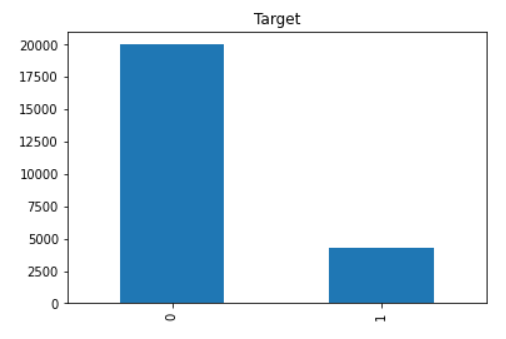

In [37]:
5/25

0.2